# IMPORT LIBRARIES

In [23]:
!pip install git+https://github.com/kratzert/RRMPG.git

  Cloning https://github.com/kratzert/RRMPG.git to /tmp/pip-req-build-ux9d21hs
  Running command git clone --filter=blob:none --quiet https://github.com/kratzert/RRMPG.git /tmp/pip-req-build-ux9d21hs
  Resolved https://github.com/kratzert/RRMPG.git to commit 7de78c25acc1c255d2acaf739d65e9ce7bbd60c3
  Preparing metadata (setup.py) ... done


In [24]:
from rrmpg.models import GR4J

In [25]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize # USE IN THE MODEL CALIBRATION

from google.colab import files
import zipfile
import os

from numba import njit
import warnings
warnings.filterwarnings('ignore')

import time

##CAMELS-DATA

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:

data_dir = "/content/drive/MyDrive/CAMELS_GB/"
start_date, end_date = '1990-01-01', '2014-12-31'

print("Loading, filtering, and aligning CSV files...\n")

# 1. Fast Load & Filter
df_pcp = pd.read_csv(f"{data_dir}pcp_mm.csv", index_col=0).loc[start_date:end_date]
df_pet = pd.read_csv(f"{data_dir}pet_mm.csv", index_col=0).loc[start_date:end_date]
df_q   = pd.read_csv(f"{data_dir}q_mmd_obs.csv", index_col=0).loc[start_date:end_date]

# 2. Fast Alignment
common_stations = sorted(list(set(df_pcp.columns) & set(df_pet.columns) & set(df_q.columns)))
df_pcp = df_pcp[common_stations]
df_pet = df_pet[common_stations]
df_q   = df_q[common_stations]

print(f"✅ Data aligned. Total common stations: {len(common_stations)}")

# ============================================
# Memory-Optimized Wrapper Classes
# ============================================
class SimpleArray:
    __slots__ = ['array']  # Prevents massive RAM bloat
    def __init__(self, array):
        self.array = array
    def to_numpy(self):
        return self.array

class StationData:
    __slots__ = ['data']
    def __init__(self, data_dict):
        self.data = data_dict
    def sel(self, dynamic_features=None):
        return SimpleArray(self.data[dynamic_features])

# ============================================
# Ultra-Fast Dictionary Construction
# ============================================
print("Building ds_recent dictionary...\n")

# Convert DataFrames to 2D NumPy matrices once (orders of magnitude faster than column iteration)
pcp_arr = df_pcp.to_numpy()
pet_arr = df_pet.to_numpy()
q_arr   = df_q.to_numpy()
date_arr = pd.to_datetime(df_pcp.index).to_numpy()

# Build the dictionary using fast index slicing
ds_recent = {
    st: StationData({
        'pcp_mm': pcp_arr[:, i],
        'pet_mm': pet_arr[:, i],
        'q_mmd_obs': q_arr[:, i],
        'date': date_arr
    })
    for i, st in enumerate(common_stations)
}

print(f"✅ Dictionary built successfully!")

# ============================================
# Validation Test
# ============================================
test_station = common_stations[0]
print(f"\nTesting data access for station: {test_station}")

Q_obs = ds_recent[test_station].sel(dynamic_features="q_mmd_obs").to_numpy()
P     = ds_recent[test_station].sel(dynamic_features="pcp_mm").to_numpy()
PET   = ds_recent[test_station].sel(dynamic_features="pet_mm").to_numpy()

print(f"✅ Extraction works correctly!")
print(f"   Q_obs shape: {Q_obs.shape}")
print(f"   Q_obs - min: {np.nanmin(Q_obs):.2f}, max: {np.nanmax(Q_obs):.2f}, mean: {np.nanmean(Q_obs):.2f}")
print(f"   Q_obs Missing: {np.sum(np.isnan(Q_obs))} ({np.sum(np.isnan(Q_obs))/len(Q_obs)*100:.1f}%)")

Loading, filtering, and aligning CSV files...

✅ Data aligned. Total common stations: 671
Building ds_recent dictionary...

✅ Dictionary built successfully!

Testing data access for station: 10002
✅ Extraction works correctly!
   Q_obs shape: (9131,)
   Q_obs - min: 0.21, max: 25.04, mean: 1.37
   Q_obs Missing: 0 (0.0%)


##Metrics

In [28]:
@njit
def NSE(obs, sim):

    n = len(obs)

    mean_obs = 0.0
    count = 0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            mean_obs += obs[i]
            count += 1

    if count == 0:
        return np.nan

    mean_obs /= count

    num = 0.0
    den = 0.0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            num += (sim[i] - obs[i])**2
            den += (obs[i] - mean_obs)**2

    if den == 0:
        return np.nan

    return 1.0 - num / den

import numpy as np
from numba import njit


@njit
def RMSE(obs, sim):

    n = len(obs)

    mse = 0.0
    count = 0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            diff = sim[i] - obs[i]
            mse += diff * diff
            count += 1

    if count == 0:
        return np.nan

    return np.sqrt(mse / count)


@njit
def FHV(obs, sim, top_fraction=0.02):

    mask = ~np.isnan(obs) & ~np.isnan(sim)

    obs = obs[mask]
    sim = sim[mask]

    if len(obs) == 0:
        return np.nan

    n_top = int(len(obs) * top_fraction)

    if n_top == 0:
        return np.nan

    idx = np.argsort(obs)[-n_top:]

    return np.sum(sim[idx] - obs[idx]) / np.sum(obs[idx])


@njit
def FLV(obs, sim, bottom_fraction=0.3):
    epsilon = 1e-6
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    n_bot = int(len(obs) * bottom_fraction)
    if n_bot == 0:
        return np.nan
    idx = np.argsort(obs)[:n_bot]
    obs_bot = obs[idx]
    sim_bot = sim[idx]
    return  np.sum(sim_bot - obs_bot) / (np.sum(obs_bot) + epsilon)


def KGE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]

    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)

    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2), r, alpha, beta

In [29]:
## General Parameters of the code
b1_ratio = 0.7
max_missing_ratio = 0.1

stations = list(ds_recent.keys())

## cGRHyMoLAP

#Q(t+1) from t+1 imputs

In [30]:
start_time = time.perf_counter()

# ============================================
# TIME DISCRETIZATION
# ============================================
dt = 0.5
nsub = int(1.0 / dt)

# ============================================
# COUPLED STORAGE + RUNOFF (S AND Q TOGETHER)
# ============================================

@njit
def cGRHyMoLAP_Model(params, Q0, Pn, En):

    MU, LAMBDA, X1, GAMMA = params

    n = len(Pn)

    Q = np.zeros(n)
    S = np.zeros(n)

    Q[0] = Q0
    S[0] = X1 / 2.0

    ratio = 4.0 / 9.0
    c = (1.0 / (4.0 * X1**4)) * ratio**4

    for t in range(n-1):

        Q_day = Q[t]
        S_day = S[t]

        for k in range(nsub):

            temp = S_day / X1

            Ps = Pn[t] * (1.0 - temp**2)
            Es = En[t] * (2.0 * temp - temp**2)

            perc = c * S_day**5

            # update S (first ODE)
            S_day = S_day + dt * (Ps - Es - perc)
            if S_day < 0:
                S_day = 0.0

            # choose forcing for Q
            if k == nsub - 1:
                P_Q = Pn[t + 1]   # last sub-step uses next-day forcing
            else:
                P_Q = Pn[t]       # otherwise current-day forcing

            dQ = (
                -(MU / LAMBDA) * Q_day**(2 * MU - 1)
                + GAMMA * (c * S_day**5) * P_Q
            )

            Q_day = Q_day + dt * dQ
            if Q_day < 0:
                Q_day = 0.0

        S[t + 1] = S_day
        Q[t + 1] = Q_day

    return Q, S


# ============================================
# MAIN LOOP (UNCHANGED STRUCTURE)
# ============================================

results_cGRH_semi_exp = {}

for i, station_id in enumerate(stations):

    print(f"\n=== Station {station_id} ===, Number = {i+1}")

    Q_obs = ds_recent[station_id].sel(
        dynamic_features="q_mmd_obs"
    ).to_numpy()

    P = ds_recent[station_id].sel(
        dynamic_features="pcp_mm"
    ).to_numpy()

    PET = ds_recent[station_id].sel(
        dynamic_features="pet_mm"
    ).to_numpy()

    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    N = len(Q_obs)

    if N == 0 or np.all(np.isnan(Q_obs)):
        continue

    if np.sum(np.isnan(Q_obs)) / N > max_missing_ratio:
        continue

    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    if np.isnan(Q0):
       Q0 = 0

    # ============================================
    # OPTIMIZATION
    # ============================================
    grhymolap_param_bound = [(0.5, 3.5), (1e-3, 300.0), (1e-3, 5000.0), (1e-3, 20.0)]

    initial_guesses = [
    [0.5, 1.0, 80, 0.05],
    [0.7, 2.0, 120, 0.1],
    [1.0, 5.0, 150, 0.2],
    [1.2, 8.0, 250, 0.3],
    [1.5, 10.0, 300, 0.5],
    [2.0, 15.0, 400, 0.8],
    [2.5, 20.0, 600, 1.0],
    [0.8, 3.0, 800, 0.2],
    [1.0, 6.0, 1000, 0.4],
    [3.0, 25.0, 200, 0.1],
    [1.0, 12.0, 1500, 0.6]
]

    best_res = None
    best_val = float("inf")

    for guess in initial_guesses:

        res = minimize(
            lambda p: RMSE(
                Q_obs[:b1],
                cGRHyMoLAP_Model(p, Q0, Pn[:b1], En[:b1])[0]
            ),
            guess,
            method="Nelder-Mead",
            bounds = grhymolap_param_bound,
            options={'maxiter': 2500, 'disp': False}
        )

        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    # ============================================
    # SIMULATION
    # ============================================

    Qsim, S = cGRHyMoLAP_Model(best_res.x, Q0, Pn, En)

    NSE_cal = NSE(Q_obs[:b1], Qsim[:b1])
    RMSE_cal = RMSE(Q_obs[:b1], Qsim[:b1])

    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])
    RMSE_val = RMSE(Q_obs[b1:], Qsim[b1:])

    FHV_val = FHV(Q_obs[b1:], Qsim[b1:])
    FLV_val = FLV(Q_obs[b1:], Qsim[b1:])

    KGE_val, KGE_1, KGE_2, KGE_3  = KGE(Q_obs[b1:], Qsim[b1:])

    results_cGRH_semi_exp[station_id] = {

        "params": best_res.x,
        "Qsim": Qsim[b1:],
        "Q_obs": Q_obs[b1:],

        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "RMSE_cal": RMSE_cal,
        "RMSE_val": RMSE_val,

        "FHV_val": FHV_val,
        "FLV_val": FLV_val,
        "KGE_val": KGE_val,
        "KGE_1": KGE_1,
        "KGE_2": KGE_2,
        "KGE_3": KGE_3,

    }

    print(f"   NSE cal: {NSE_cal:.4f}")
    print(f"   NSE val: {NSE_val:.4f}")

print(f"\n✅ Simulation completed for {len(results_cGRH_semi_exp)} basins.")

end_time = time.perf_counter()

total_time = end_time - start_time

print(f"Total time: {total_time:.2f} s")
print(f"Total time: {total_time/60:.2f} min")
print(f"Total time: {total_time/3600:.2f} h")


=== Station 10002 ===, Number = 1
   NSE cal: 0.7267
   NSE val: 0.5784

=== Station 10003 ===, Number = 2
   NSE cal: 0.8255
   NSE val: 0.7400

=== Station 1001 ===, Number = 3

=== Station 101002 ===, Number = 4
   NSE cal: 0.7122
   NSE val: 0.7268

=== Station 101005 ===, Number = 5
   NSE cal: 0.7254
   NSE val: 0.7467

=== Station 102001 ===, Number = 6
   NSE cal: 0.7616
   NSE val: 0.7596

=== Station 106001 ===, Number = 7

=== Station 107001 ===, Number = 8

=== Station 11001 ===, Number = 9
   NSE cal: 0.7676
   NSE val: 0.6135

=== Station 11003 ===, Number = 10
   NSE cal: 0.6137
   NSE val: 0.4055

=== Station 11004 ===, Number = 11
   NSE cal: 0.7617
   NSE val: 0.6438

=== Station 12001 ===, Number = 12
   NSE cal: 0.5713
   NSE val: 0.4177

=== Station 12002 ===, Number = 13
   NSE cal: 0.6361
   NSE val: 0.5008

=== Station 12005 ===, Number = 14
   NSE cal: 0.6001
   NSE val: 0.5158

=== Station 12006 ===, Number = 15
   NSE cal: 0.4838
   NSE val: 0.3061

=== Stat

In [31]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_cGRH_semi_exp.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_cGRH_semi_exp.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for the calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for the calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_cGRH_semi_exp.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_cGRH_semi_exp.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for NSE in validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.806, 5th percentile: 0.6220, 95th percentile: 0.9194
MEAN NSE_CAL: 0.7936621766867769
MIN NSE_CAL: 0.07304998458679124
MAX NSE_CAL: 0.9549542051990341

--- RMSE Calibration ---
RMSE Calibration -> Median: 0.811, 5th percentile: 0.1433, 95th percentile: 2.8108
MEAN RMSE_CAL: 1.0868414748663728
MIN RMSE_CAL: 0.04672436164643337
MAX RMSE_CAL: 10.340772625522007


================= VALIDATION =================

NSE Validation -> Median: 0.775, 5th percentile: 0.5059, 95th percentile: 0.9010
MEAN NSE_VAL: 0.7485988142633893
MIN NSE_VAL: -1.6026846465582323
MAX NSE_VAL: 0.9543120396178172

--- RMSE Validation ---
RMSE Validation -> Median: 0.981, 5th percentile: 0.1643, 95th percentile: 3.1147
MEAN RMSE_VAL: 1.2268823586878501
MIN RMSE_VAL: 0.03782940631501979
MAX RMSE_VAL: 10.02939666652994


#GRHyMoLAP

In [32]:
start_time = time.perf_counter()

# ============================================
# NUMBA FUNCTIONS
# ============================================

@njit
def Percolation(Pn, En, X1):
    n = len(Pn)
    S = np.zeros(n)
    Perc = np.zeros(n)

    S[0] = X1 / 2.0
    ratio = (4.0 / 9.0) * (S[0] / X1)
    Perc[0] = S[0] * (1 - (1 + ratio**4) ** (-0.25))

    for i in range(1, n):
        temp = (S[i-1] / X1) ** 2

        frac = Pn[i] / X1
        Ps = X1 * (1 - temp) * np.tanh(frac) / (1 + (S[i-1] / X1) * np.tanh(frac))

        frac = En[i] / X1
        Es = S[i-1] * (2 - S[i-1]/X1) * np.tanh(frac) / (1 + (1 - S[i-1]/X1) * np.tanh(frac))

        S[i] = S[i-1] + Ps - Es

        ratio = (4.0 / 9.0) * (S[i] / X1)
        Perc[i] = S[i] * (1 - (1 + ratio**4) ** (-0.25))

        S[i] -= Perc[i]

    return Perc, S


@njit
def GRHyMoLAP_Model(params, Q0, Pn, En):
    MU, LAMBDA, X1, GAMMA = params
    N = len(Pn)

    Q = np.zeros(N)
    Q[0] = Q0

    Perc, S = Percolation(Pn, En, X1)

    for t in range(N-1):
        Q[t+1] = max(
            0.0,
            Q[t]
            - (MU / LAMBDA) * (Q[t])**(2*MU - 1)
            + GAMMA * Perc[t+1] * Pn[t+1]
        )

    return Q

# ============================================
# SETTINGS
# ============================================

results_GRH_semi_exp = {}

# ============================================
# MAIN LOOP
# ============================================

for i, station_id in enumerate(stations):

    print(f"\n=== Station {station_id} ===, Number = {i+1}")

    Q_obs = ds_recent[station_id].sel(dynamic_features="q_mmd_obs").to_numpy()
    P     = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    PET   = ds_recent[station_id].sel(dynamic_features="pet_mm").to_numpy()

    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station skipped (no valid data).")
        continue

    missing_ratio = np.sum(np.isnan(Q_obs)) / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too many missing values ({missing_ratio*100:.1f}%)")
        continue

    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    if np.isnan(Q0):
       Q0 = 0

    # ============================================
    # OPTIMIZATION
    # ============================================
    grhymolap_param_bound = [(0.5, 3.5), (1e-3, 300.0), (1e-3, 5000.0), (1e-3, 20.0)]

    initial_guesses = [
    [0.5, 1.0, 80, 0.05],
    [0.7, 2.0, 120, 0.1],
    [1.0, 5.0, 150, 0.2],
    [1.2, 8.0, 250, 0.3],
    [1.5, 10.0, 300, 0.5],
    [2.0, 15.0, 400, 0.8],
    [2.5, 20.0, 600, 1.0],
    [0.8, 3.0, 800, 0.2],
    [1.0, 6.0, 1000, 0.4],
    [3.0, 25.0, 200, 0.1],
    [1.0, 12.0, 1500, 0.6]
]

    best_res = None
    best_val = float("inf")

    for guess in initial_guesses:
        res = minimize(
            lambda p: RMSE(
                Q_obs[:b1],
                GRHyMoLAP_Model(p, Q0, Pn[:b1], En[:b1])
            ),
            guess,
            method="Nelder-Mead",
            bounds = grhymolap_param_bound,
            options={'maxiter': 2500, 'disp': False}
        )

        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    MU, LAMBDA, X1, GAMMA = best_res.x

    # ============================================
    # SIMULATION
    # ============================================

    Qsim = GRHyMoLAP_Model(best_res.x, Q0, Pn, En)

    NSE_cal = NSE(Q_obs[:b1], Qsim[:b1])
    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])
    RMSE_cal = RMSE(Q_obs[:b1], Qsim[:b1])
    RMSE_val = RMSE(Q_obs[b1:], Qsim[b1:])

    FHV_val = FHV(Q_obs[b1:], Qsim[b1:])
    FLV_val = FLV(Q_obs[b1:], Qsim[b1:])
    KGE_val, KGE_1, KGE_2, KGE_3  = KGE(Q_obs[b1:], Qsim[b1:])

    S = Percolation(Pn, En, X1)[1]

    # ============================================
    # STORE RESULTS (FULL PRESERVED)
    # ============================================

    results_GRH_semi_exp[station_id] = {
        "params": [MU, LAMBDA, X1, GAMMA],
        "Qsim": Qsim[b1:],
        "Q_obs": Q_obs[b1:],

        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "RMSE_cal": RMSE_cal,
        "RMSE_val": RMSE_val,

        "FHV_val": FHV_val,
        "FLV_val": FLV_val,
        "KGE_val": KGE_val,
        "KGE_1": KGE_1,
        "KGE_2": KGE_2,
        "KGE_3": KGE_3,

    }

    print(f" NSE cal: {NSE_cal:.4f}")
    print(f" NSE val: {NSE_val:.4f}")

print(f"\n✅ Simulation completed for {len(results_GRH_semi_exp)} valid basins.")

end_time = time.perf_counter()

total_time = end_time - start_time

print(f"Total time: {total_time:.2f} s")
print(f"Total time: {total_time/60:.2f} min")
print(f"Total time: {total_time/3600:.2f} h")


=== Station 10002 ===, Number = 1
 NSE cal: 0.6854
 NSE val: 0.5358

=== Station 10003 ===, Number = 2
 NSE cal: 0.8382
 NSE val: 0.7503

=== Station 1001 ===, Number = 3
⚠️ Too many missing values (23.4%)

=== Station 101002 ===, Number = 4
 NSE cal: 0.7321
 NSE val: 0.7423

=== Station 101005 ===, Number = 5
 NSE cal: 0.7511
 NSE val: 0.7790

=== Station 102001 ===, Number = 6
 NSE cal: 0.7238
 NSE val: 0.7415

=== Station 106001 ===, Number = 7
⚠️ Too many missing values (28.0%)

=== Station 107001 ===, Number = 8
⚠️ Too many missing values (38.4%)

=== Station 11001 ===, Number = 9
 NSE cal: 0.7615
 NSE val: 0.5962

=== Station 11003 ===, Number = 10
 NSE cal: 0.6508
 NSE val: 0.4247

=== Station 11004 ===, Number = 11
 NSE cal: 0.8031
 NSE val: 0.6859

=== Station 12001 ===, Number = 12
 NSE cal: 0.5688
 NSE val: 0.4072

=== Station 12002 ===, Number = 13
 NSE cal: 0.6314
 NSE val: 0.4927

=== Station 12005 ===, Number = 14
 NSE cal: 0.6272
 NSE val: 0.5267

=== Station 12006 ===

In [33]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_GRH_semi_exp.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_GRH_semi_exp.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for the calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for the calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_GRH_semi_exp.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_GRH_semi_exp.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for NSE in validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.787, 5th percentile: 0.6281, 95th percentile: 0.9092
MEAN NSE_CAL: 0.7814399107592024
MIN NSE_CAL: 0.05885001050479077
MAX NSE_CAL: 0.9506259493912581

--- RMSE Calibration ---
RMSE Calibration -> Median: 0.841, 5th percentile: 0.1503, 95th percentile: 2.8037
MEAN RMSE_CAL: 1.1133037143574298
MIN RMSE_CAL: 0.048459348307743545
MAX RMSE_CAL: 10.242094881778334


================= VALIDATION =================

NSE Validation -> Median: 0.758, 5th percentile: 0.5169, 95th percentile: 0.8908
MEAN NSE_VAL: 0.7346496349288566
MIN NSE_VAL: -1.7026746467237177
MAX NSE_VAL: 0.9507097595818322

--- RMSE Validation ---
RMSE Validation -> Median: 1.010, 5th percentile: 0.1719, 95th percentile: 3.0532
MEAN RMSE_VAL: 1.2528198740823604
MIN RMSE_VAL: 0.03968719486955541
MAX RMSE_VAL: 10.076058049280638


#GR4J

In [34]:
start_time = time.perf_counter()

# ============================================
# General infos
# ============================================

results_GR4J = {}

# ============================================
# GR4J objective function (minimize RMSE)
# ============================================
def objective_gr4j(x, Q, P, ET):
    model = GR4J()
    params = dict(zip(model.get_parameter_names(), x))
    model.set_params(params)
    try:
        Qsim = model.simulate(P, ET).flatten()
        rmse = RMSE(Q, Qsim)
        return rmse if np.isfinite(rmse) else 1e6
    except Exception:
        return 1e6


# ============================================
# GR4J bounds
# ============================================
bounds = [
    (1, 3500),   # x1
    (-15, 15),   # x2
    (1, 1200),   # x3
    (0.5, 5)     # x4
]

# ============================================
# Main loop over basins
# ============================================
for i, station_id in enumerate(stations, start=1):

    print(f"\n=== Station {station_id} ({i}/{len(stations)}) ===")

    Q_obs = ds_recent[station_id].sel(dynamic_features="q_mmd_obs").to_numpy()
    P = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    ET = ds_recent[station_id].sel(dynamic_features="pet_mm").to_numpy()

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station ignored (no valid data)")
        continue

    missing_ratio = np.isnan(Q_obs).sum() / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too many missing values ({missing_ratio*100:.1f}%)")
        continue

    # ============================================
    # Split calibration / validation
    # ============================================
    b1 = int(N * b1_ratio)

    Q_cal, Q_val = Q_obs[:b1], Q_obs[b1:]
    P_cal, P_val = P[:b1], P[b1:]
    ET_cal, ET_val = ET[:b1], ET[b1:]

    # ============================================
    # Multi-start calibration
    # ============================================
    best_fun = np.inf
    best_x = None
    np.random.seed(42)

    for _ in range(20):
        x0 = [np.random.uniform(b[0], b[1]) for b in bounds]

        res = minimize(
            objective_gr4j,
            x0,
            args=(Q_cal, P_cal, ET_cal),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 3000}
        )

        if res.fun < best_fun:
            best_fun = res.fun
            best_x = res.x

    if best_x is None:
        print("⚠️ Calibration failed")
        continue

    # ============================================
    # Final simulation
    # ============================================
    model = GR4J()
    params = dict(zip(model.get_parameter_names(), best_x))
    model.set_params(params)

    Qsim_cal = model.simulate(P_cal, ET_cal).flatten()
    Qsim_val = model.simulate(P_val, ET_val).flatten()

    # ============================================
    # Metrics
    # ============================================
    nse_cal = NSE(Q_cal, Qsim_cal)
    rmse_cal = RMSE(Q_cal, Qsim_cal)

    nse_val = NSE(Q_val, Qsim_val)
    rmse_val = RMSE(Q_val, Qsim_val)

    FHV_val = FHV(Q_val, Qsim_val)
    FLV_val = FLV(Q_val, Qsim_val)
    KGE_val, KGE_1, KGE_2, KGE_3  = KGE(Q_val, Qsim_val)

    # ============================================
    # Store results
    # ============================================
    results_GR4J[station_id] = {
        "NSE_cal": nse_cal,
        "RMSE_cal": rmse_cal,
        "NSE_val": nse_val,
        "RMSE_val": rmse_val,
        "FHV_val": FHV_val,
        "FLV_val": FLV_val,
        "KGE_val": KGE_val,
        "KGE_1": KGE_1,
        "KGE_2": KGE_2,
        "KGE_3": KGE_3,

        "Qsim": Qsim_val,
        "Q_obs": Q_val,
        **params
    }

    # ============================================
    # Display
    # ============================================
    print(f"NSE calibration   : {nse_cal:.3f}")
    print(f"NSE validation    : {nse_val:.3f}")

print(f"\n✅ Finished : {len(results_GR4J)} calibrated basins")

end_time = time.perf_counter()

total_time = end_time - start_time

print(f"Total time: {total_time:.2f} s")
print(f"Total time: {total_time/60:.2f} min")
print(f"Total time: {total_time/3600:.2f} h")


=== Station 10002 (1/671) ===
NSE calibration   : 0.839
NSE validation    : 0.685

=== Station 10003 (2/671) ===
NSE calibration   : 0.876
NSE validation    : 0.695

=== Station 1001 (3/671) ===
⚠️ Too many missing values (23.4%)

=== Station 101002 (4/671) ===
NSE calibration   : 0.720
NSE validation    : 0.656

=== Station 101005 (5/671) ===
NSE calibration   : 0.736
NSE validation    : 0.808

=== Station 102001 (6/671) ===
NSE calibration   : 0.791
NSE validation    : 0.781

=== Station 106001 (7/671) ===
⚠️ Too many missing values (28.0%)

=== Station 107001 (8/671) ===
⚠️ Too many missing values (38.4%)

=== Station 11001 (9/671) ===
NSE calibration   : 0.845
NSE validation    : 0.613

=== Station 11003 (10/671) ===
NSE calibration   : 0.700
NSE validation    : 0.401

=== Station 11004 (11/671) ===
NSE calibration   : 0.839
NSE validation    : 0.585

=== Station 12001 (12/671) ===
NSE calibration   : 0.583
NSE validation    : 0.411

=== Station 12002 (13/671) ===
NSE calibration 

In [35]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_GR4J.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_GR4J.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_GR4J.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_GR4J.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.814, 5th percentile: 0.5673, 95th percentile: 0.9007
MEAN NSE_CAL: 0.7826899265047589
MIN NSE_CAL: -0.5286319282541476
MAX NSE_CAL: 0.9550577706677827

--- RMSE Calibration ---
RMSE Calibration -> Median: 0.757, 5th percentile: 0.1865, 95th percentile: 2.7695
MEAN RMSE_CAL: 1.0628525730765996
MIN RMSE_CAL: 0.0805996707558844
MAX RMSE_CAL: 10.52069210892935


================= VALIDATION =================

NSE Validation -> Median: 0.759, 5th percentile: 0.1968, 95th percentile: 0.8877
MEAN NSE_VAL: 0.665496505753149
MIN NSE_VAL: -3.6695473000443
MAX NSE_VAL: 0.9553012114514174

--- RMSE Validation ---
RMSE Validation -> Median: 0.931, 5th percentile: 0.2520, 95th percentile: 3.0295
MEAN RMSE_VAL: 1.2335054870412532
MIN RMSE_VAL: 0.1305648855778599
MAX RMSE_VAL: 10.089213602640902


##HBV

In [36]:
start_time = time.perf_counter()

# ============================================
# 1️⃣ General setting
# ============================================

results_HBV = {}

# ============================================
# 3️⃣ HBV
# ============================================
@njit
def hbv_numba(P, ET, params):
    FC, BETA, LP, K0, K1, K2, UZL, PERC = params

    SM = 0.5 * FC
    UZ = 0.0
    LZ = 0.0

    n = len(P)
    Qsim = np.zeros(n)

    for t in range(n):
        p = P[t]
        et = ET[t]

        # Soil moisture
        soil_ratio = SM / FC
        recharge = p * soil_ratio**BETA
        SM += p - recharge
        if SM > FC:
            recharge += SM - FC
            SM = FC
        evap = min(et * min(SM / (LP * FC), 1.0), SM)
        SM -= evap

        # Upper reservoir
        UZ += recharge
        perc = min(PERC, UZ)
        UZ -= perc
        LZ += perc

        # Quick flow
        Q0 = K0 * (UZ - UZL) if UZ > UZL else 0.0
        if Q0 > 0:
            UZ -= Q0

        # Interflow
        Q1 = K1 * UZ
        UZ -= Q1

        # Baseflow
        Q2 = K2 * LZ
        LZ -= Q2

        # Total discharge
        Qsim[t] = max(0.0, Q0 + Q1 + Q2)

    return Qsim

# ============================================
# 4️⃣ Fonction objective
# ============================================
def objective_hbv(x, Q, P, ET):
    Qsim = hbv_numba(P, ET, x)
    nse = NSE(Q, Qsim)
    return 1 - nse if np.isfinite(nse) else 1e6

# ============================================
# 5️⃣ Boucle sur stations
# ============================================
bounds = [
    (50,1000), (1,6), (0.3,1), (0,0.5), (0,0.3),
    (0,0.1), (0,100), (0,5)
]

for i, station_id in enumerate(stations, start=1):
    print(f"\n=== Station {station_id} ({i}/{len(stations)}) ===")

    Q_obs = ds_recent[station_id].sel(dynamic_features="q_mmd_obs").to_numpy()
    P     = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    ET   = ds_recent[station_id].sel(dynamic_features="pet_mm").to_numpy()

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        continue

    missing_ratio = np.sum(np.isnan(Q_obs)) / N
    if missing_ratio > max_missing_ratio:
        continue

    # Calibration / validation
    b1 = int(N * b1_ratio)
    Q_cal, Q_val = Q_obs[:b1], Q_obs[b1:]
    P_cal, P_val = P[:b1], P[b1:]
    ET_cal, ET_val = ET[:b1], ET[b1:]

    # Multi-start calibration
    best_fun = np.inf
    best_x = None
    np.random.seed(42)
    for _ in range(20):
        x0 = [np.random.uniform(b[0], b[1]) for b in bounds]
        res = minimize(
            objective_hbv,
            x0,
            args=(Q_cal, P_cal, ET_cal),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter":3000}
        )
        if res.fun < best_fun:
            best_fun = res.fun
            best_x = res.x

    if best_x is None:
        continue

    Qsim_cal = hbv_numba(P_cal, ET_cal, best_x)
    Qsim_val = hbv_numba(P_val, ET_val, best_x)

    # ============================================
    # Metrics
    # ============================================
    nse_cal = NSE(Q_cal, Qsim_cal)
    rmse_cal = RMSE(Q_cal, Qsim_cal)

    nse_val = NSE(Q_val, Qsim_val)
    rmse_val = RMSE(Q_val, Qsim_val)

    FHV_val = FHV(Q_val, Qsim_val)
    FLV_val = FLV(Q_val, Qsim_val)
    KGE_val, KGE_1, KGE_2, KGE_3  = KGE(Q_val, Qsim_val)

    # ============================================
    # Store results
    # ============================================
    results_HBV[station_id] = {
        "NSE_cal": nse_cal,
        "RMSE_cal": rmse_cal,
        "NSE_val": nse_val,
        "RMSE_val": rmse_val,
        "FHV_val": FHV_val,
        "FLV_val": FLV_val,
        "KGE_val": KGE_val,
        "KGE_1": KGE_1,
        "KGE_2": KGE_2,
        "KGE_3": KGE_3,

        "Qsim": Qsim_val,
        "Q_obs": Q_val,
        **params
    }

    # ============================================
    # Display
    # ============================================
    print(f"NSE calibration   : {nse_cal:.3f}")
    print(f"NSE validation    : {nse_val:.3f}")

print(f"\n✅ Finished : {len(results_HBV)} calibrated basins")

end_time = time.perf_counter()

total_time = end_time - start_time

print(f"Total time: {total_time:.2f} s")
print(f"Total time: {total_time/60:.2f} min")
print(f"Total time: {total_time/3600:.2f} h")


=== Station 10002 (1/671) ===
NSE calibration   : 0.718
NSE validation    : 0.577

=== Station 10003 (2/671) ===
NSE calibration   : 0.849
NSE validation    : 0.751

=== Station 1001 (3/671) ===

=== Station 101002 (4/671) ===
NSE calibration   : 0.757
NSE validation    : 0.680

=== Station 101005 (5/671) ===
NSE calibration   : 0.761
NSE validation    : 0.783

=== Station 102001 (6/671) ===
NSE calibration   : 0.719
NSE validation    : 0.737

=== Station 106001 (7/671) ===

=== Station 107001 (8/671) ===

=== Station 11001 (9/671) ===
NSE calibration   : 0.802
NSE validation    : 0.600

=== Station 11003 (10/671) ===
NSE calibration   : 0.723
NSE validation    : 0.443

=== Station 11004 (11/671) ===
NSE calibration   : 0.836
NSE validation    : 0.681

=== Station 12001 (12/671) ===
NSE calibration   : 0.604
NSE validation    : 0.424

=== Station 12002 (13/671) ===
NSE calibration   : 0.671
NSE validation    : 0.517

=== Station 12005 (14/671) ===
NSE calibration   : 0.660
NSE validat

In [37]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_HBV.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_HBV.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_HBV.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_HBV.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.800, 5th percentile: 0.6036, 95th percentile: 0.9002
MEAN NSE_CAL: 0.7725328054385868
MIN NSE_CAL: -3.447807221879847
MAX NSE_CAL: 0.9325791809293669

--- RMSE Calibration ---
RMSE Calibration -> Median: 0.817, 5th percentile: 0.1733, 95th percentile: 2.8321
MEAN RMSE_CAL: 1.1114939896616236
MIN RMSE_CAL: 0.04552008312855641
MAX RMSE_CAL: 11.270362337036808


================= VALIDATION =================

NSE Validation -> Median: 0.745, 5th percentile: 0.3972, 95th percentile: 0.8720
MEAN NSE_VAL: 0.6919879710927853
MIN NSE_VAL: -1.93217546028034
MAX NSE_VAL: 0.9264208679489333

--- RMSE Validation ---
RMSE Validation -> Median: 1.010, 5th percentile: 0.2272, 95th percentile: 3.0277
MEAN RMSE_VAL: 1.2825234862607102
MIN RMSE_VAL: 0.08054866929574574
MAX RMSE_VAL: 10.43881874381692


#Recession

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

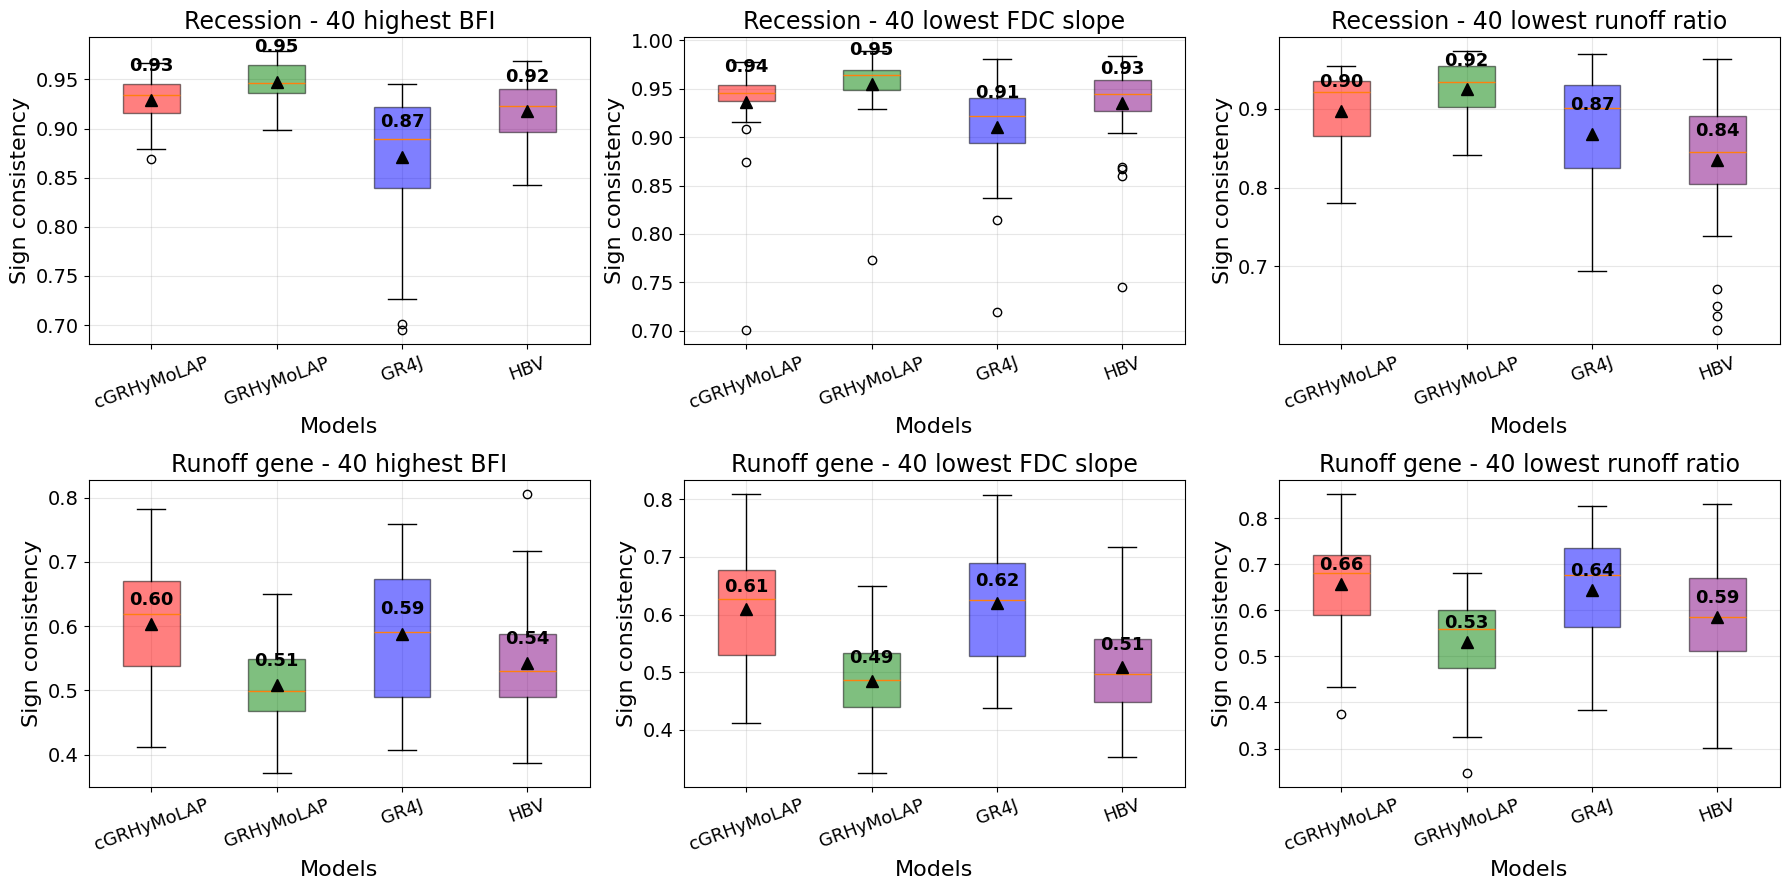

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 0. LOAD ATTRIBUTES
# =========================================================

hydro = pd.read_csv(
    '/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_hydrologic_attributes.csv',
    sep=','
)

hydro["gauge_id"] = hydro["gauge_id"].astype(str)

df = hydro[[
    "gauge_id",
    "baseflow_index",
    "slope_fdc",
    "runoff_ratio"
]].dropna()

# =========================================================
# 1. DEFINE BASIN GROUPS
# =========================================================

top_bfi = set(
    df.sort_values("baseflow_index", ascending=False)
      .head(40)["gauge_id"]
)

low_fdc = set(
    df.sort_values("slope_fdc", ascending=True)
      .head(40)["gauge_id"]
)

low_rr = set(
    df.sort_values("runoff_ratio", ascending=True)
      .head(40)["gauge_id"]
)

groups = {
    "Top BFI": top_bfi,
    "Low FDC slope": low_fdc,
    "Low runoff ratio": low_rr
}


# =========================================================
# 2. MODELS
# =========================================================

models = {
    "cGRHyMoLAP": results_cGRH_semi_exp,
    "GRHyMoLAP": results_GRH_semi_exp,
    "GR4J": results_GR4J,
    "HBV": results_HBV
}

model_names = list(models.keys())


# =========================================================
# 3. SEGMENTATION
# =========================================================

def extract_recession_segments(
    Q,
    eps=0.0,
    remove_first_days=0,
    min_length=7,
):

    Q = np.asarray(Q)

    dQ = Q[1:] - Q[:-1]

    recession = dQ <= eps

    segments_of_difference_indices = []

    current = []

    for i, flag in enumerate(recession):

        if flag:

            current.append(i )

        else:

            if len(current):

                seg = current[remove_first_days:]

                if len(seg) >= min_length:
                    segments_of_difference_indices.append(np.array(seg))

                current = []

    if len(current):

        seg = current[remove_first_days:]

        if len(seg) >= min_length:
            segments_of_difference_indices.append(np.array(seg))

    return segments_of_difference_indices



def extract_runoff_generation_segments(
    Q,
    eps=0.0,
):

    Q = np.asarray(Q)

    dQ = Q[1:] - Q[:-1]

    runoff = dQ > eps

    segments_of_difference_indices = []

    current = []

    for i, flag in enumerate(runoff):

        if flag:

            current.append(i )

        else:

            if len(current):

                segments_of_difference_indices.append(np.array(current))

                current = []

    if len(current):

        segments_of_difference_indices.append(np.array(current))

    return segments_of_difference_indices



# =========================================================
# 4. SIGN CONSISTENCY
# =========================================================

def sign_consistency(
    Q_mod,
    segments,
    regime,
):

    violations = 0
    total = 0

    dQsim = np.diff(Q_mod)

    for seg in segments:

        dq = dQsim[seg]

        total += len(dq)

        if regime == "recession":

            violations += np.sum(dq > 0)

        else:

            violations += np.sum(dq <= 0)

    if total == 0:
        return np.nan

    return 1 - violations / total


# =========================================================
# 4. COMPUTE METRICS FOR A GROUP
# =========================================================

def compute_group(basin_set):

    rec = {m: [] for m in model_names}
    rg = {m: [] for m in model_names}

    for sid in results_HBV.keys():

        sid = str(sid)

        if sid not in basin_set:
            continue

        try:
            Q_obs = np.asarray(results_HBV[sid]["Q_obs"], dtype=float)

            Q_models = {
                m: np.asarray(models[m][sid]["Qsim"], dtype=float)
                for m in model_names
            }

            rec_segs = extract_recession_segments(Q_obs)
            rg_segs = extract_runoff_generation_segments(Q_obs)

            for m in model_names:

                sr = sign_consistency(Q_models[m], rec_segs, "recession")
                sg = sign_consistency(Q_models[m], rg_segs, "runoff")

                if not np.isnan(sr):
                    rec[m].append(sr)
                if not np.isnan(sg):
                    rg[m].append(sg)

        except:
            continue

    return rec, rg


# =========================================================
# 5. COMPUTE ALL GROUPS
# =========================================================

rec_bfi, rg_bfi = compute_group(groups["Top BFI"])
rec_fdc, rg_fdc = compute_group(groups["Low FDC slope"])
rec_rr, rg_rr = compute_group(groups["Low runoff ratio"])


# =========================================================
# 6. PLOTTING FUNCTION
# =========================================================

def plot_box(ax, data_dict, title):

    colors = {
        "cGRHyMoLAP": "red",
        "GRHyMoLAP": "green",
        "GR4J": "blue",
        "HBV": "purple"
    }

    data = []
    means = []

    for m in model_names:
        vals = np.asarray(data_dict[m])
        vals = vals[~np.isnan(vals)]

        data.append(vals)
        means.append(np.mean(vals))

    bp = ax.boxplot(
        data,
        patch_artist=True,
        showmeans=True,
        meanprops=dict(
            marker='^',          # triangle
            markerfacecolor='black',
            markeredgecolor='black',
            markersize=8
        )
    )

    # =====================================================
    # box colors
    # =====================================================
    for patch, m in zip(bp["boxes"], model_names):
        patch.set_facecolor(colors[m])
        patch.set_alpha(0.5)

    # =====================================================
    # mean annotation (bigger + clean)
    # =====================================================
    for i, mean_val in enumerate(means, start=1):
        ax.text(
            i,
            mean_val + 0.03,
            f"{mean_val:.2f}",
            ha="center",
            fontsize=13,
            fontweight="bold",
            color="black"
        )

    # =====================================================
    # AXES styling (IMPORTANT)
    # =====================================================
    ax.set_xticks(np.arange(1, len(model_names) + 1))
    ax.set_xticklabels(model_names, rotation=20, fontsize=13)

    ax.set_ylabel("Sign consistency", fontsize=16)
    ax.set_xlabel("Models", fontsize=16)

    ax.set_title(title, fontsize=17)

    ax.tick_params(axis='y', labelsize=14)
    ax.grid(alpha=0.3)


# =========================================================
# 7. FIGURE 3x2
# =========================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# row 1 = recession
plot_box(axes[0,0], rec_bfi, "Recession - 40 highest BFI")
plot_box(axes[0,1], rec_fdc, "Recession - 40 lowest FDC slope")
plot_box(axes[0,2], rec_rr, "Recession - 40 lowest runoff ratio")

# row 2 = runoff generation
plot_box(axes[1,0], rg_bfi, "Runoff gene - 40 highest BFI")
plot_box(axes[1,1], rg_fdc, "Runoff gene - 40 lowest FDC slope")
plot_box(axes[1,2], rg_rr, "Runoff gene - 40 lowest runoff ratio")

plt.tight_layout()

plt.savefig(
    "recession.jpeg",
    dpi=700,
    bbox_inches="tight"
)
#files.download("recession.jpeg")

plt.show()

In [39]:
print("hydro example:", hydro["gauge_id"].iloc[0])
print("results example:", list(results_HBV.keys())[0])

hydro example: 10002
results example: 10002
